In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Bangladesh_Crime_Dataset_A.csv")
df.head(10)

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,...,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
0,0,7.0,29,wednesday,0,morning,dhaka,dhaka,6.1,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
1,1,1.0,2,wednesday,0,night,dhaka,dhaka,0.0,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
2,2,1.0,4,tuesday,0,night,dhaka,dhaka,0.0,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
3,3,3.0,9,friday,1,night,dhaka,dhaka,0.0,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
4,4,8.0,34,thursday,0,night,dhaka,dhaka,21.9,9,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
5,5,8.0,34,thursday,0,night,dhaka,dhaka,21.9,9,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
6,6,2.0,7,sunday,0,night,dhaka,dhaka,0.6,10,...,3.77,4948.0,68.0,1118,78,3,6,42,10,murder
7,7,1.0,1,saturday,1,evening,dhaka,dhaka,0.0,10,...,3.77,4948.0,68.0,1118,78,3,6,42,10,murder
8,8,NaN,2,friday,1,evening,dhaka,dhaka,0.0,10,...,3.77,4948.0,68.0,1118,78,3,6,42,10,murder
9,9,2.0,7,sunday,0,night,dhaka,dhaka,0.6,10,...,3.77,4948.0,68.0,1118,78,3,6,42,10,murder


## a) EDA

### 1. Cek Dataset Secara Keseluruhan

In [3]:
df.shape

(6574, 26)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              6574 non-null   int64  
 1   incident_month          5917 non-null   float64
 2   incident_week           6574 non-null   int64  
 3   incident_weekday        6574 non-null   object 
 4   weekend                 6574 non-null   int64  
 5   part_of_the_day         6457 non-null   object 
 6   incident_district       6246 non-null   object 
 7   incident_division       6574 non-null   object 
 8   precip                  6574 non-null   float64
 9   visibility              6574 non-null   int64  
 10  heatindex               6574 non-null   int64  
 11  season                  6574 non-null   object 
 12  male_population         6574 non-null   int64  
 13  female_population       6574 non-null   int64  
 14  total_population        6574 non-null   

### 2. Cek Duplikat

In [5]:
df.duplicated().sum()

0

Berdasarkan hasil yang didapatkan, dapat diketahui bahwa dalam dataset ini tidak terdapat data yang duplikat

### 3. Cek Kolom yang Relevan

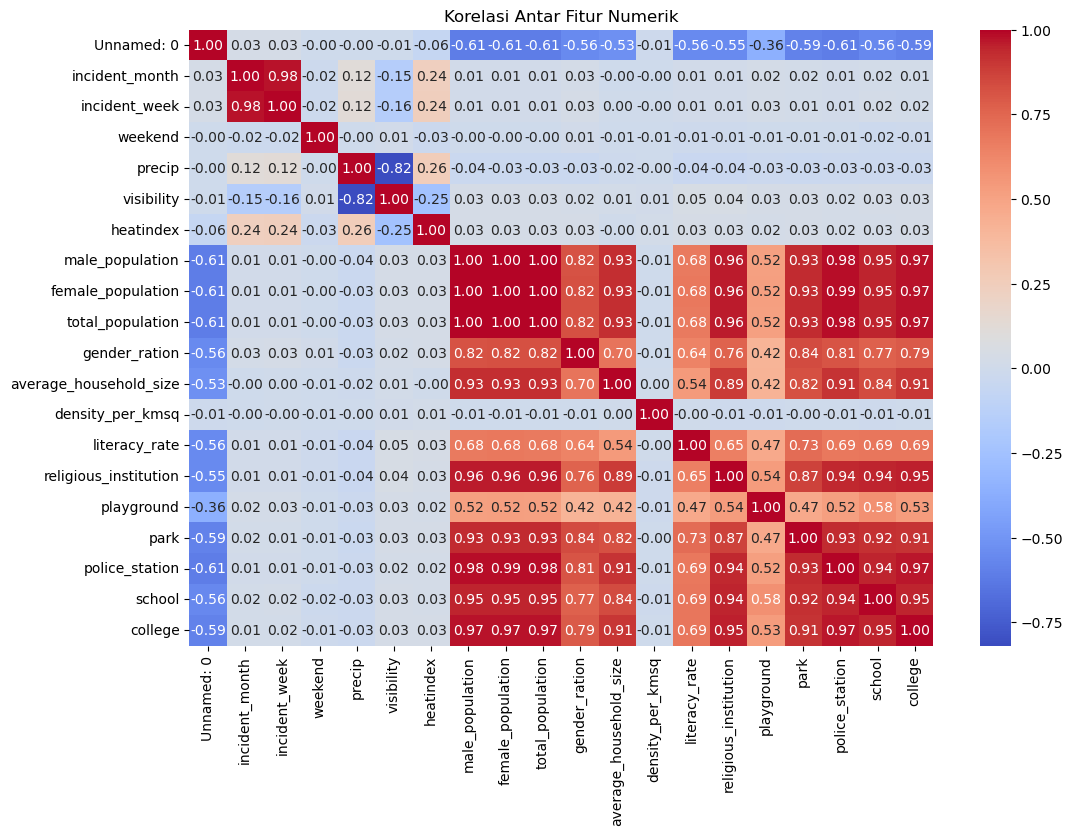

In [6]:
import seaborn as sns

#Menghitung korelasi untuk kolom numerik
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

Berdasarkan heatmap tersebut, kita dapat melihat kolom-kolom yang saling berkorelasi maupun tidak. Dalam modelling ini, saya akan drop kolom yang memiliki korelasi tinggi ataupun memiliki informasi yang redundan. Kolom yang akan di drop adalah:
* incident_week --> redundan dengan incident_weekday dan incident_month.
* weekend --> sudah ada incident_weekday
* visibility --> sudah cukup dengan precip
* male_population dan female_population --> sudah ada total_population dan gender_ratio

Kolom religious_institution, playground, park, police_station, school, dan college memiliki tingkat korelasi yang cukup tinggi satu sama lain namun tidak akan saya drop melainkan akan diproses lebih lanjut

Selain itu, dari kolom kategorikal saya juga akan drop kolom incident_district dikarenakan kolom incident_division sudah cukup mewakili lokasi secara umum. Selain itu, kolom season juga akan di drop karena bisa dianggap bahwa datanya merupakan turunan dari incident_month

In [7]:
#Drop kolom yang tidak relevan
df = df.drop(columns=[
    'Unnamed: 0', 'season', 'incident_district', 'incident_week', 
    'visibility', 'weekend', 'male_population', 'female_population'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          5917 non-null   float64
 1   incident_weekday        6574 non-null   object 
 2   part_of_the_day         6457 non-null   object 
 3   incident_division       6574 non-null   object 
 4   precip                  6574 non-null   float64
 5   heatindex               6574 non-null   int64  
 6   total_population        6574 non-null   int64  
 7   gender_ration           6574 non-null   int64  
 8   average_household_size  6574 non-null   float64
 9   density_per_kmsq        6574 non-null   float64
 10  literacy_rate           6246 non-null   float64
 11  religious_institution   6574 non-null   int64  
 12  playground              6574 non-null   int64  
 13  park                    6574 non-null   int64  
 14  police_station          6574 non-null   

### 4. Cek Inkonsistensi

In [9]:
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    print(df[col].value_counts(dropna=False), "\n")

incident_weekday
tuesday      1010
monday        984
wednesday     976
thursday      937
saturday      917
friday        883
sunday        867
Name: count, dtype: int64 

part_of_the_day
night        3179
morning      1946
noon          517
evening       484
afternoon     331
NaN           117
Name: count, dtype: int64 

incident_division
dhaka         1806
chattogram     918
rajshahi       700
rangpur        626
khulna         611
              ... 
RAngpuR          1
rAJSHaHi         1
MyMensINgH       1
sylheT           1
cHATtOGRam       1
Name: count, Length: 192, dtype: int64 

crime
murder       1518
bodyfound    1517
rape         1193
assault      1097
kidnap        651
robbery       598
Name: count, dtype: int64 



Berdasarkan hasil cek tersebut, dapat dilihat bahwa kebanyakan kolom sudah konsisten. Meskipun begitu, pada kolom 'incident_division' masih terdapat banyak data yang penulisannya tidak konsisten sehingga harus di handle terlebih dahulu

In [10]:
#Ubah penulisan menjadi huruf kecil semua dan hapus spasi jika ada lalu cek data kembali
df['incident_division'] = df['incident_division'].str.lower().str.strip()
df['incident_division'].unique()

array(['dhaka', 'gazipur', 'chattogram', 'rajshahi', 'khulna', 'barisal',
       'sylhet', 'rangpur', 'mymensingh'], dtype=object)

### 5. Cek Missing Values

In [11]:
df.isna().sum()

incident_month            657
incident_weekday            0
part_of_the_day           117
incident_division           0
precip                      0
heatindex                   0
total_population            0
gender_ration               0
average_household_size      0
density_per_kmsq            0
literacy_rate             328
religious_institution       0
playground                  0
park                        0
police_station              0
school                      0
college                     0
crime                       0
dtype: int64

#### - Kolom Numerik

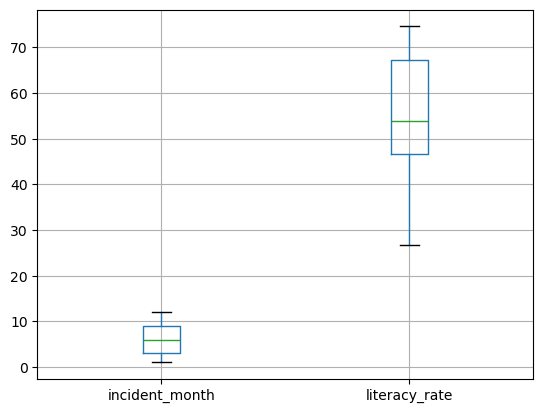

In [12]:
bp = df.boxplot(column=['incident_month', 'literacy_rate'])
plt.show()

In [13]:
#Mengisi NaN atau missing values dengan median
df['incident_month'].fillna(df['incident_month'].median(), inplace=True)
df['literacy_rate'].fillna(df['literacy_rate'].median(), inplace=True)

#### - Kolom Kategorikal

In [14]:
#Mengisi NaN atau missing values dengan modus
df['part_of_the_day'] = df['part_of_the_day'].fillna(df['part_of_the_day'].mode()[0])

#### - Cek Ulang

In [15]:
df.isna().sum()

incident_month            0
incident_weekday          0
part_of_the_day           0
incident_division         0
precip                    0
heatindex                 0
total_population          0
gender_ration             0
average_household_size    0
density_per_kmsq          0
literacy_rate             0
religious_institution     0
playground                0
park                      0
police_station            0
school                    0
college                   0
crime                     0
dtype: int64

## b) Train dan Tuning

#### 1. Penentuan Kolom

##### - Pembuatan Kolom facility_index

In [16]:
from sklearn.preprocessing import StandardScaler
#Kolom fasilitas yang digabung
facility_cols = ['religious_institution', 'playground', 'park', 'police_station','school','college']

#Standardisasi fasilitas
scaler_facility = StandardScaler()
facility_scaled = scaler_facility.fit_transform(df[facility_cols])

#Buat facility index (penjumlahan skor standar)
df['facility_index'] = facility_scaled.sum(axis=1)

#Frop kolom fasilitas asli
df.drop(columns=facility_cols, inplace=True)

In [17]:
kmeans_cols = [
    'incident_month', 'incident_weekday', 'part_of_the_day', 'precip',
    'heatindex', 'total_population', 'gender_ration', 'average_household_size',
    'density_per_kmsq', 'literacy_rate', 'facility_index'
]

In [18]:
df['facility_index'].describe()

count    6.574000e+03
mean    -2.766945e-16
std      5.471876e+00
min     -4.907031e+00
25%     -3.356171e+00
50%     -2.322365e+00
75%     -1.718865e-01
max      1.319381e+01
Name: facility_index, dtype: float64

##### - Pisahkan Data yang Digunakan

In [19]:
X = df[kmeans_cols].copy()

### 2. Encode Kolom Kategorikal

In [20]:
from sklearn.preprocessing import OneHotEncoder
ohe_cols = ['incident_weekday', 'part_of_the_day']

#One-hot encoding
ohc = OneHotEncoder()
X_ohe = pd.DataFrame(ohc.fit_transform(X[ohe_cols]).toarray(), columns=ohc.get_feature_names_out(ohe_cols))
X = X.reset_index(drop=True)
X_ohe = X_ohe.reset_index(drop=True)
X_encoded = pd.concat([X.drop(columns=ohe_cols), X_ohe],axis=1)

### 3. Scaling

In [21]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

### 4. Baseline Modelling

In [22]:
from sklearn.cluster import KMeans

#Baseline model menggunakan k=3 sebagai titik awal
kmeans_baseline = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

baseline_labels = kmeans_baseline.fit_predict(X_scaled)
df['cluster_baseline'] = baseline_labels

In [23]:
from sklearn.metrics import silhouette_score

baseline_silhouette = silhouette_score(X_scaled, baseline_labels)
baseline_silhouette

0.1288777951258589

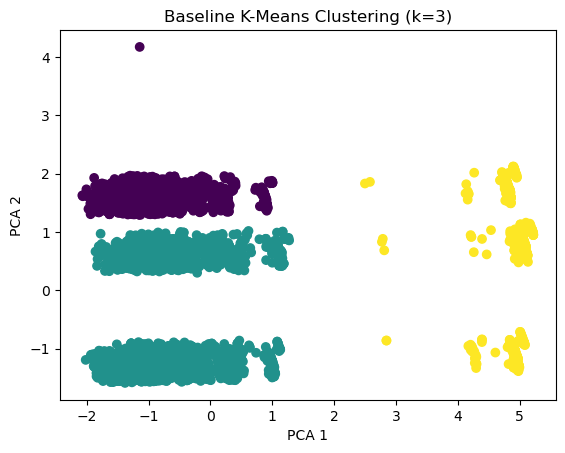

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster_baseline'],
    cmap='viridis'
)
plt.title('Baseline K-Means Clustering (k=3)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

### 5. Tuning

In [25]:
K_range = range(2, 11)

#### 1) Elbow Method (Inertia)

In [26]:
inertia = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

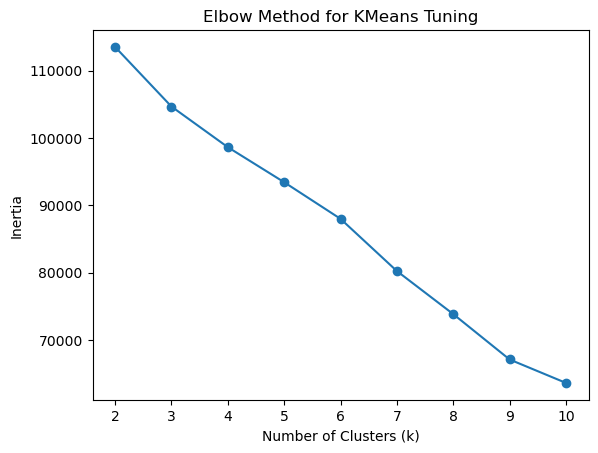

In [27]:
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for KMeans Tuning')
plt.show()


#### 2) Silhouette Score

In [28]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

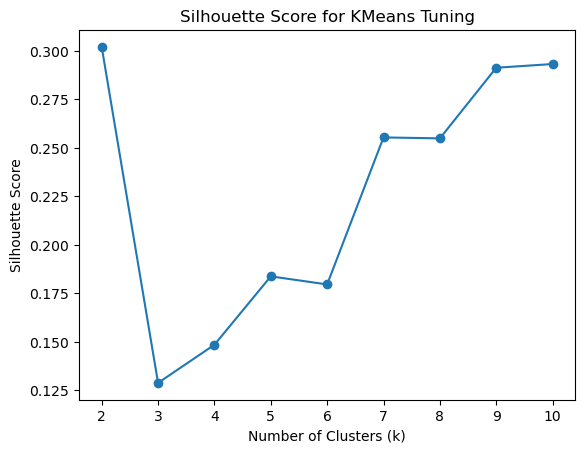

In [29]:
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for KMeans Tuning')
plt.show()

In [30]:
tuning_results = pd.DataFrame({
    'k': list(K_range),
    'inertia': inertia,
    'silhouette_score': silhouette_scores
})
tuning_results

,k,inertia,silhouette_score
0,2,113510.970870,0.302069
1,3,104658.843618,0.128878
2,4,98623.093332,0.148551
3,5,93416.124336,0.183804
4,6,87977.292300,0.179645
5,7,80222.331987,0.255425
6,8,73828.077923,0.254933
7,9,67086.708098,0.291338
8,10,63607.689486,0.293253


Berdasarkan hasil evaluasi, nilai $k=2$ dipilih sebagai jumlah cluster optimal karena memiliki Silhouette Score tertinggi dan titik siku (Elbow) yang paling signifikan. Hal ini menunjukkan bahwa secara matematis, pembagian menjadi dua kelompok menghasilkan pemisahan antar-cluster yang paling tajam dan struktur data yang paling stabil untuk diinterpretasikan.

#### Model Final

In [31]:
kmeans_k2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df['cluster_k2'] = kmeans_k2.fit_predict(X_scaled)

sil_k2 = silhouette_score(X_scaled, df['cluster_k2'])
sil_k2

0.30206880490025234

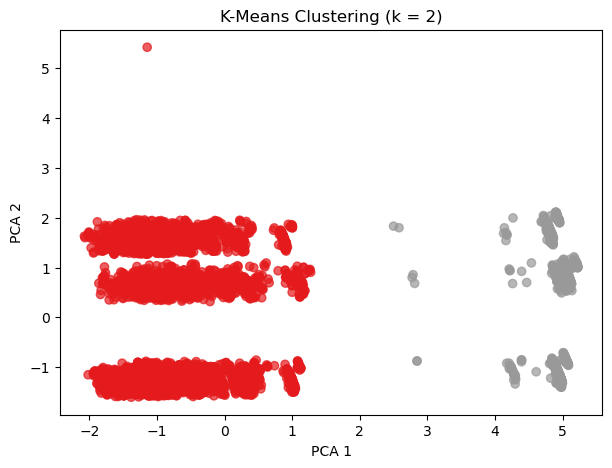

In [32]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster_k2'],
    cmap='Set1',
    alpha=0.7
)
plt.title('K-Means Clustering (k = 2)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()


### d) Profiling Each Cluster

In [33]:
df_profile = df.copy()

#Kolom yang digunakan
numerical_features = [
    'incident_month', 'precip', 'heatindex', 'total_population', 
    'gender_ration', 'average_household_size', 'density_per_kmsq', 
    'literacy_rate', 'facility_index'
]
categorical_features = ['incident_weekday', 'part_of_the_day', 'incident_division', 'crime']

#Analisis kolom numerik (rata-rata tiap cluster)
print("Rata-rata Karakteristik Numerik per Cluster")
profile_num = df_profile.groupby('cluster_k2')[numerical_features].mean()
display(profile_num.round(2))

#Analisis kolom kategorikal & target (proporsi dalam %)
print("\nDistribusi Fitur Kategorikal & Target per Cluster (%)")
for col in categorical_features:
    print(f"\n>> Persentase {col.replace('_', ' ').title()}:")
    #Membuat tabel silang (crosstab) dalam bentuk persentase baris
    dist = pd.crosstab(df_profile['cluster_k2'], df_profile[col], normalize='index') * 100
    display(dist.round(2))

Rata-rata Karakteristik Numerik per Cluster


,incident_month,precip,heatindex,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,facility_index
cluster_k2,,,,,,,,,
0,6.18,6.34,31.54,538519.28,101.16,4.44,2.183113e+52,52.92,-2.01
1,6.27,5.19,32.00,8837053.76,125.62,8.39,2.488715e+43,73.34,13.05



Distribusi Fitur Kategorikal & Target per Cluster (%)

>> Persentase Incident Weekday:


incident_weekday,friday,monday,saturday,sunday,thursday,tuesday,wednesday
cluster_k2,,,,,,,
0,13.40,14.84,14.06,12.59,14.22,15.59,15.29
1,13.65,15.81,13.20,17.06,14.45,13.88,11.95



>> Persentase Part Of The Day:


part_of_the_day,afternoon,evening,morning,night,noon
cluster_k2,,,,,
0,4.76,7.30,30.54,50.13,7.27
1,6.83,7.74,23.55,50.17,11.72



>> Persentase Incident Division:


incident_division,barisal,chattogram,dhaka,gazipur,khulna,mymensingh,rajshahi,rangpur,sylhet
cluster_k2,,,,,,,,,
0,7.16,18.63,20.61,0.07,12.24,7.88,13.73,12.34,7.32
1,0.00,0.00,99.20,0.00,0.00,0.00,0.00,0.00,0.80



>> Persentase Crime:


crime,assault,bodyfound,kidnap,murder,rape,robbery
cluster_k2,,,,,,
0,16.45,22.51,10.24,24.34,18.75,7.71
1,18.20,26.73,7.74,15.02,14.22,18.09


In [34]:
#Mengidentifikasi modus tiap cluster untuk fitur kategorikal
profile_cat_mode = (
    df_profile
    .groupby('cluster_k2')[categorical_features]
    .agg(lambda x: x.mode()[0])
)

display(profile_cat_mode)

,incident_weekday,part_of_the_day,incident_division,crime
cluster_k2,,,,
0,tuesday,night,dhaka,murder
1,sunday,night,dhaka,bodyfound


#### Insight

1. Karakteristik Cluster 0:
* Profil Demografi & Lingkungan: Cluster ini memiliki rata-rata total_population dan density_per_kmsq yang lebih moderat dibandingkan Cluster 1. Nilai facility_index yang dimiliki tergolong rendah (-2.01), menunjukkan wilayah dengan fasilitas publik yang sangat kurang.
* Pola Waktu: Berdasarkan fitur part_of_the_day, kejahatan di cluster ini sering terjadi pada waktu Night (Malam Hari). Selain itu, diketahui pula bahwa aktivitas kejahatan di sini cukup tersebar merata di hari kerja (Selasa & Rabu).
* Lokasi & Kejahatan: Wilayah kejahatan pada cluster ini dipimpin oleh Dhaka dan diikuti oleh kota lainnya seperti Chattogram dan Rajshahi (incident_division). Jenis kejahatan (crime) yang paling sering muncul adalah kejahatan berat (misal: Murder atau Bodyfound).
* Insight: Keterbatasan fasilitas publik di wilayah ini berkorelasi dengan tingginya kemunculan kejahatan berat, yang umumnya terjadi pada malam hari di kawasan urban dengan kepadatan dan populasi moderat.

2. Karakteristik Cluster 1:
* Profil Demografi & Lingkungan: Memiliki literacy_rate (tingkat literasi) dan kepadatan penduduk serta populasi yang cenderung lebih tinggi dibandingkan Cluster 0. 
* Pola Waktu: Waktu kejadian kejahatan berdasarkan fitur part_of_the_day didominasi pada waktu Night (Malam hari) dan diikuti oleh Morning (Pagi hari). Aktivitas kejahatan di cluster ini lebih sering terjadi pada hari minggu (Sunday).
* Lokasi & Kejahatan: Berdasarkan fitur incident_division, kejahatan pada cluster ini berpusat di satu daerah yaitu Dhaka (99.20%). Jenis kejahatan yang dominan biasanya adalah Bodyfound diikuti oleh Assault.
* Insight: Kepadatan ekonomi di Dhaka berbanding lurus dengan tingginya kasus kejahatan. Munculnya Dhaka sebagai cluster tunggal membuktikan bahwa ibu kota memiliki profil risiko kriminalitas yang sangat berbeda dan tidak bisa disamakan dengan wilayah lain.